# AIMMD-TPS with Toy Systems

This notebook demonstrates how to use AIMMD (Artificial Inteligence Molecular Mechanism Discovery) with TPS on toy potentials.

AIMMD learns reaction coordinates from the sampling, which is more efficient than manually defining them.
We'll use the ops-setup toy systems infrastructure combined with AIMMD training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openpathsampling as paths
from pathlib import Path

# Import from ops-setup
from ops_setup.systems.examples.toy_systems import ToyTPSSetup, potential_1

from aimmdTIS import aimmd_setup
import aimmdTIS 
import aimmd
print("Imports successful!")

/Users/rbreeba/code/aimmd/aimmd/base/storage.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



Imports successful!


In [2]:
%load_ext autoreload
%autoreload 2

## 1.a Setup TPS with ops-setup

We use the ops-setup TIS infrastructure, which provides clean initialization and network creation.

In [3]:
# Setup TIS for toy potential 1
tps_setup = ToyTPSSetup(
    potential_name='wolfe-quapp',
    potential_kwargs={'n_harmonics': 0, 'rotation_degrees': 0, 'scale': 2},
    integrator_params={
        'dt': 0.05,
        'temperature': 1,
        'gamma': 2.5
    }
)

print(f"System: {tps_setup.system_name}")
print(f"Engine: {tps_setup.md_engine.name}")

Setting up Langevin BAOAB integrator for toy system...
seed used for harmonic oscilattors 123
pot dimensions without oscillators: 2
harmonic oscillators omegas:
array([0., 0.])
Setting up Langevin BAOAB integrator for toy system...
Setting up toy engine for wolfe-quapp...
Creating snapshot template for toy system...
Defining states for wolfe-quapp...
System: wolfe-quapp
Engine: [ToyEngine]


In [4]:
# setup visualization tools


## 1.a Setup AIMMD 
setup AIMMD using aimmd-setup infrastructure.

In [ ]:
config = {
  "system_name": "CB7-B2", 
  "settings": {},
  "AIMMD_settings": {
    "distribution": "lorentzian",
    "scale": 1.0,
    "activation": "ReLU",
    "use_GPU": True,
    "ee_params": {
      "lr_0": 0.001,
      "lr_min": 1e-7,
      'epochs_per_train': 5,  # train for 5 epochs every time we train
      'interval': 5,  # attempt to train after every 3rd MCStep
      'window': 75,  # average expected efficiency factor over 100 MCSteps
    },
    "layers": {
      "0": 64,
      "1": 32
    },
    "dropout": {
      "0": 0.1,
      "1": 0.05
    }
  }
}
aimmd_set = aimmd_setup.AIMMDSetup(config, 
                                    descriptor_dim=tps_setup.pes.n_dims_pot,
                                    states=tps_setup.states, 
                                    print_config=True)

system_name: CB7-B2
settings: 
AIMMD_settings: 
    distribution: lorentzian
    scale: 1.0
    activation: ReLU
    use_GPU: True
    ee_params: 
        lr_0: 0.001
        lr_min: 1e-07
        epochs_per_train: 5
        interval: 5
        window: 75
    layers: 
        0: 64
        1: 32
    dropout: 
        0: 0.1
        1: 0.05


## 2. Run TPS Sampling with AIMMD selector

First, run pure TPS to generate trajectories

In [6]:
tps_aimmd_storage_filename = 'aimmd_storage_test_{}.h5'.format(tps_setup.system_name)
print(tps_aimmd_storage_filename)
tps_ops_storage_filename = "toy_aimmd_tps_sampling_{}.nc".format(tps_setup.system_name)
print(tps_ops_storage_filename)

aimmd_storage_test_wolfe-quapp.h5
toy_aimmd_tps_sampling_wolfe-quapp.nc


In [7]:
# Create engine reference
paths.PathMover.engine = tps_setup.md_engine

# Initial trajectory
print("Creating initial trajectory...")
init_traj = paths.Trajectory(tps_setup.pes.simple_initial_path(200, tps_setup.md_engine))
# Create TIS network
print("Creating TPS network...")
network = tps_setup.create_network()

tps_aimmd_storage_filename = 'aimmd_storage_test_{}.h5'.format(tps_setup.system_name)
# aimmd specific setup 
aimmd_storage = aimmd.Storage(tps_aimmd_storage_filename, "w")
aimmd_model = aimmd_set.setup_RCModel(aimmd_storage)
selector = aimmd_set.setup_selector(aimmd_model)

trainset = aimmd.TrainSet(n_states=2)
trainhook = aimmd.ops.TrainingHook(aimmd_model, trainset)
storehook = aimmd.ops.AimmdStorageHook(aimmd_storage, aimmd_model, trainset)
densityhook = aimmd.ops.DensityCollectionHook(aimmd_model)

move_scheme = tps_setup.create_move_scheme(network, "TwoWay", selector=selector)


# Initialize sampling


initial_conditions = move_scheme.initial_conditions_from_trajectories(init_traj)
initial_conditions.sanity_check()


print("Initializing TPS sampling...")
storage = paths.Storage("toy_aimmd_tps_sampling_{}.nc".format(tps_setup.system_name), "w", template=tps_setup.template)
storage.save(tps_setup.template)
storage.save(tps_setup.md_engine)
storage.save(move_scheme)
storage.save(network)


No missing ensembles.
No extra ensembles.
Initializing TPS sampling...


(store.networks[TransitionNetwork] : 1 object(s),
 13,
 292518117545183053311999853772067045814)

In [8]:

# Run TPS
print("\nRunning TPS for 100 MC steps (to generate initial model)...")
sampler = paths.PathSampling(storage, move_scheme, initial_conditions)
sampler.attach_hook(trainhook)
sampler.attach_hook(storehook)
sampler.attach_hook(densityhook)

sampler.run(100)

print(f"TPS sampling complete!")
print(f"Total trajectories: {len(storage.steps)}")

Working on Monte Carlo cycle number 100
Running for 34 seconds -  0.34 seconds per step
Estimated time remaining: 0 seconds
DONE! Completed 100 Monte Carlo cycles.
TPS sampling complete!
Total trajectories: 101


In [9]:
tps_model = aimmd_storage.rcmodels["most_recent"]

In [10]:
print([k for k in aimmd_storage.rcmodels.keys()])

['RCModel_after_step_100', 'most_recent']


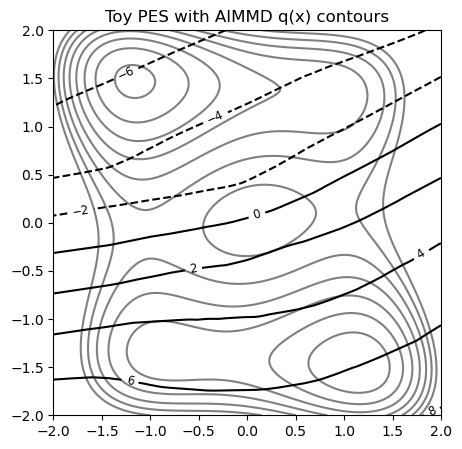

In [11]:
# Visualizer example: PES + model q(x) contours
from aimmdTIS.visualization import ToyVisualizer
tps_model.nnet.to(tps_model._device)
viz = ToyVisualizer(pes=tps_setup.pes, temperature=tps_setup.integrator_params['temperature'])
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

viz.plot_potential_contour(ax=ax)
viz.plot_q_contours(
    tps_model,
    ax=ax,
    levels=viz.levels_q,
    colors="k",
    linewidths=1.5,
 )
ax.set_title("Toy PES with AIMMD q(x) contours")
plt.show()

In [12]:
storage.close()
aimmd_storage.close()

In [13]:
aimmd_storage_tps = aimmd.Storage(tps_aimmd_storage_filename, "r")
tps_model = aimmd_storage_tps.rcmodels["most_recent"]
tps_model.nnet.to(tps_model._device);

ops_storage_tps = paths.Storage(tps_ops_storage_filename, "r")

In [14]:
interface_example = 0.0



<Axes: >

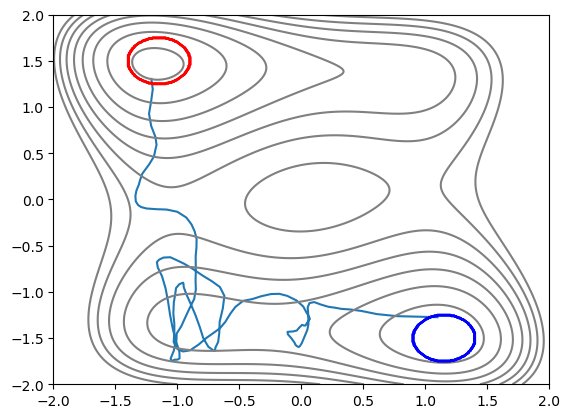

In [15]:
initial_path_TIS = ops_storage_tps.steps[-1].active[0].trajectory

plt.plot(initial_path_TIS.xyz[:,0,0], initial_path_TIS.xyz[:,0,1])
viz.plot_potential_contour(ax=plt.gca())
viz.plot_states(ax=plt.gca())

In [16]:
aimmdTISclass = aimmdTIS.AIMMD_TIS(engine=tps_setup.md_engine, AIMMD_model=tps_model, stateA=tps_setup.states[0], stateB=tps_setup.states[1],directory="", use_transform = False, model_pkl=False)


aimmd_tis_storage_filename = 'aimmd_tis_storage_{}_i{}.nc'.format(tps_setup.system_name, str(interface_example))

tis_ops_storage = paths.Storage(aimmd_tis_storage_filename, "w", template=tps_setup.template)
tis_ops_storage.save(tps_setup.template)
tis_ops_storage.save(tps_setup.md_engine)


(store.engines[DynamicsEngine] : 1 object(s),
 10,
 292518117545183053311999853772067045400)

In [17]:

aimmdTISclass.run_single_TIS(100, 
                       tis_ops_storage, 
                       initial_path_TIS, 
                       interface_example, 
                       scheme_move="TwoWay", 
                       scheme_selector="Gaussian", 
                       scheme_modifier="RandomVelocities",
                       gaussian_parameter_width=0.5, 
                       gausssian_parameter_shift=0.2,
                       direction="forward", 
                       directory="")

No missing ensembles.
No extra ensembles.


TypeError: h5py objects cannot be pickled